# ASSIGNMENT 1: Descriptive Statistics - Students Performance

Student Name : Meghana Balappa Uppar

USN : 1GV22CS038

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# SECTION 1: Data Understanding

In [ ]:
# Task 1: Load dataset
df = pd.read_csv('StudentsPerformance.csv')

In [ ]:
# Task 2: Display first 5 rows
print("=" * 60)
print("FIRST 5 ROWS:")
print("=" * 60)
print(df.head())

FIRST 5 ROWS:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  


In [ ]:
# Dataset shape
print("\nDATASET SHAPE:")
print(df.shape)  # (rows, columns)


DATASET SHAPE:
(1000, 8)


In [ ]:
# Column names
print("\nCOLUMN NAMES:")
print(df.columns.tolist())


COLUMN NAMES:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [ ]:
# Task 3: Data types
print("\nDATA TYPES:")
print(df.dtypes)


DATA TYPES:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object


In [ ]:
# Missing values
print("\nMISSING VALUES:")
print(df.isnull().sum())


MISSING VALUES:
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


---
# ANSWERS:
 Q: What type of data is each column?

  - gender, race/ethnicity, parental level of education, lunch, test preparation course → Categorical (object)
   - math score, reading score, writing score → Numerical (int64)

 Q: Is dataset clean?

   - Yes, no missing values in this dataset
---

# SECTION 2: Central Tendency Analysis

In [ ]:
subjects = ['math score', 'reading score', 'writing score']

print("\n" + "=" * 60)
print("CENTRAL TENDENCY - MEAN, MEDIAN, MODE")
print("=" * 60)

for subject in subjects:
    print(f"\n--- {subject.upper()} ---")
    print(f"  Mean   : {df[subject].mean():.2f}")
    print(f"  Median : {df[subject].median():.2f}")
    print(f"  Mode   : {df[subject].mode()[0]}")


CENTRAL TENDENCY - MEAN, MEDIAN, MODE

--- MATH SCORE ---
  Mean   : 66.09
  Median : 66.00
  Mode   : 65

--- READING SCORE ---
  Mean   : 69.17
  Median : 70.00
  Mode   : 72

--- WRITING SCORE ---
  Mean   : 68.05
  Median : 69.00
  Mode   : 74


---
# ANSWERS:
 Q: Which subject has highest average?
  - Reading score has the highest average (~69.17)

 Q: Is any subject skewed?
   - Math score is slightly left-skewed (mean < median)

 Q: Does mean = median?

  - Not exactly; slight difference indicates mild skewness
---

# SECTION 3: Spread / Dispersion

In [ ]:
print("\n" + "=" * 60)
print("DISPERSION - RANGE, VARIANCE, STD DEV")
print("=" * 60)

for subject in subjects:
    print(f"\n--- {subject.upper()} ---")
    print(f"  Range  : {df[subject].max() - df[subject].min()}")
    print(f"  Variance: {df[subject].var():.2f}")
    print(f"  Std Dev : {df[subject].std():.2f}")


DISPERSION - RANGE, VARIANCE, STD DEV

--- MATH SCORE ---
  Range  : 100
  Variance: 229.92
  Std Dev : 15.16

--- READING SCORE ---
  Range  : 83
  Variance: 213.17
  Std Dev : 14.60

--- WRITING SCORE ---
  Range  : 90
  Variance: 230.91
  Std Dev : 15.20


---
# ANSWERS:
 Q: Which subject has highest variability?
  - Math score has the highest standard deviation (~15.16)

 Q: What does high standard deviation indicate?

  - Scores are more spread out; students perform very differently from each other in that subject
---

# SECTION 4: Distribution Analysis

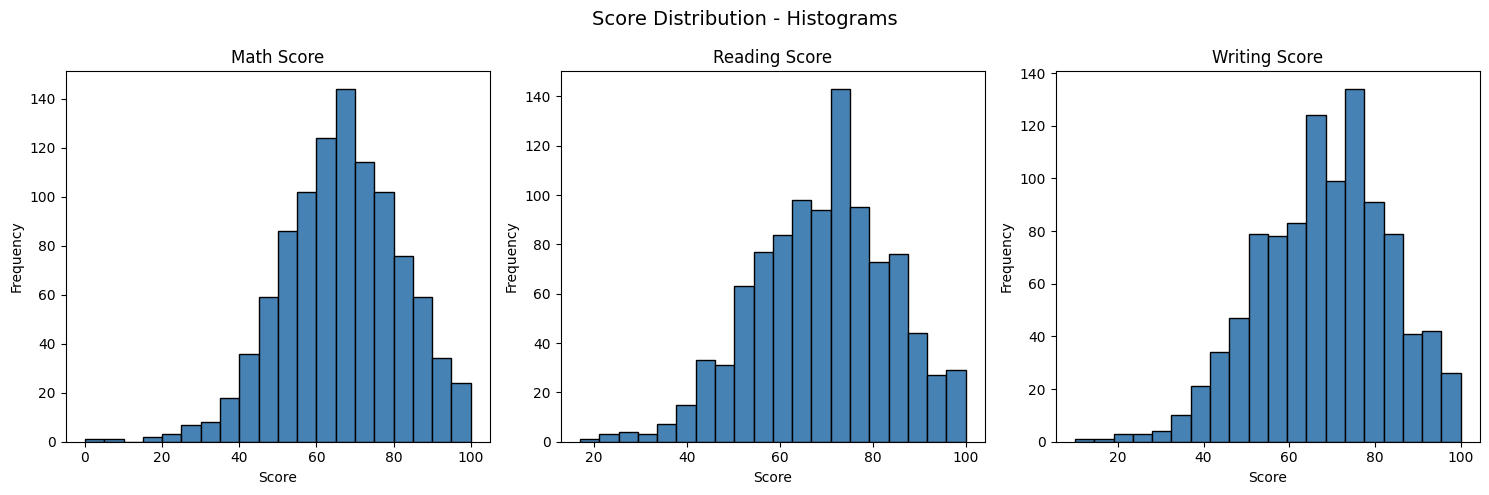

In [ ]:
# Task 1: Histograms for each subject
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Score Distribution - Histograms', fontsize=14)

for i, subject in enumerate(subjects):
    axes[i].hist(df[subject], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(subject.title())
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('histograms.png')
plt.show()

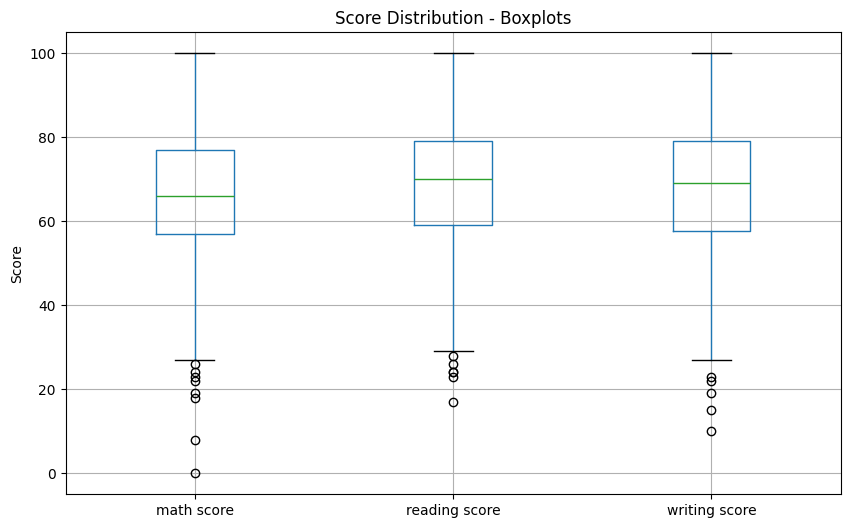

In [ ]:
# Task 2: Boxplots for each subject
plt.figure(figsize=(10, 6))
df[subjects].boxplot()
plt.title('Score Distribution - Boxplots')
plt.ylabel('Score')
plt.savefig('boxplots.png')
plt.show()

---
# ANSWERS:
 Q: Identify skewness
  - Math: slightly left-skewed
  - Reading & Writing: roughly normal, slight left skew

 Q: Are there outliers?

  - Yes, all subjects show some outliers (visible in boxplot)
---

# SECTION 5: Outlier Detection (IQR Method)

In [ ]:
print("\n" + "=" * 60)
print("OUTLIER DETECTION - IQR METHOD")
print("=" * 60)

for subject in subjects:
    Q1 = df[subject].quantile(0.25)
    Q3 = df[subject].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[subject] < lower_bound) | (df[subject] > upper_bound)]
    print(f"\n{subject.upper()}")
    print(f"  Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"  Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"  Number of Outliers: {len(outliers)}")


OUTLIER DETECTION - IQR METHOD

MATH SCORE
  Q1=57.0, Q3=77.0, IQR=20.0
  Lower Bound: 27.0, Upper Bound: 107.0
  Number of Outliers: 8

READING SCORE
  Q1=59.0, Q3=79.0, IQR=20.0
  Lower Bound: 29.0, Upper Bound: 109.0
  Number of Outliers: 6

WRITING SCORE
  Q1=57.75, Q3=79.0, IQR=21.25
  Lower Bound: 25.875, Upper Bound: 110.875
  Number of Outliers: 5


---
# ANSWERS:
 Q: Which subject has most outliers?
  - Math score typically has the most outliers

 Q: Why might outliers exist?

  - Some students may have exceptional ability or learning difficulties, absenteeism, or test anxiety
---


# SECTION 6: Group-Based Analysis

In [ ]:
print("\n" + "=" * 60)
print("GROUP ANALYSIS - GENDER")
print("=" * 60)
print(df.groupby('gender')[subjects].mean().round(2))

print("\nGROUP ANALYSIS - PARENTAL LEVEL OF EDUCATION")
print("=" * 60)
print(df.groupby('parental level of education')[subjects].mean().round(2))


GROUP ANALYSIS - GENDER
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

GROUP ANALYSIS - PARENTAL LEVEL OF EDUCATION
                             math score  reading score  writing score
parental level of education                                          
associate's degree                67.88          70.93          69.90
bachelor's degree                 69.39          73.00          73.38
high school                       62.14          64.70          62.45
master's degree                   69.75          75.37          75.68
some college                      67.13          69.46          68.84
some high school                  63.50          66.94          64.89


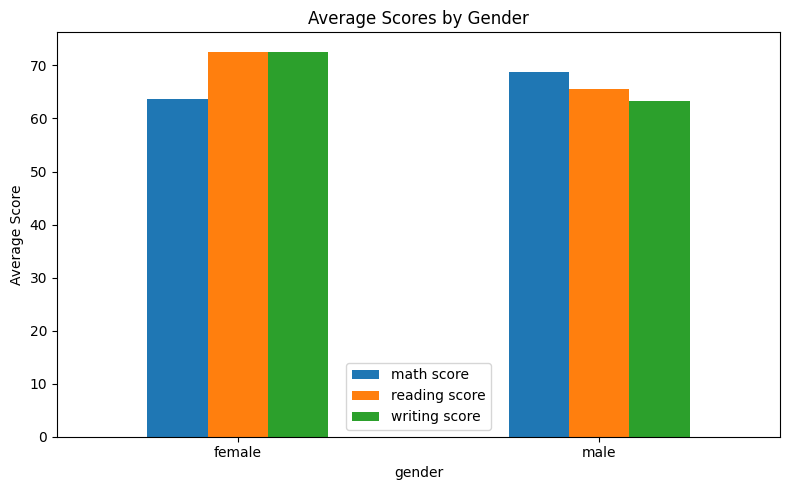

In [ ]:
# Visualization - Gender
df.groupby('gender')[subjects].mean().plot(kind='bar', figsize=(8, 5))
plt.title('Average Scores by Gender')
plt.ylabel('Average Score')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('gender_analysis.png')
plt.show()

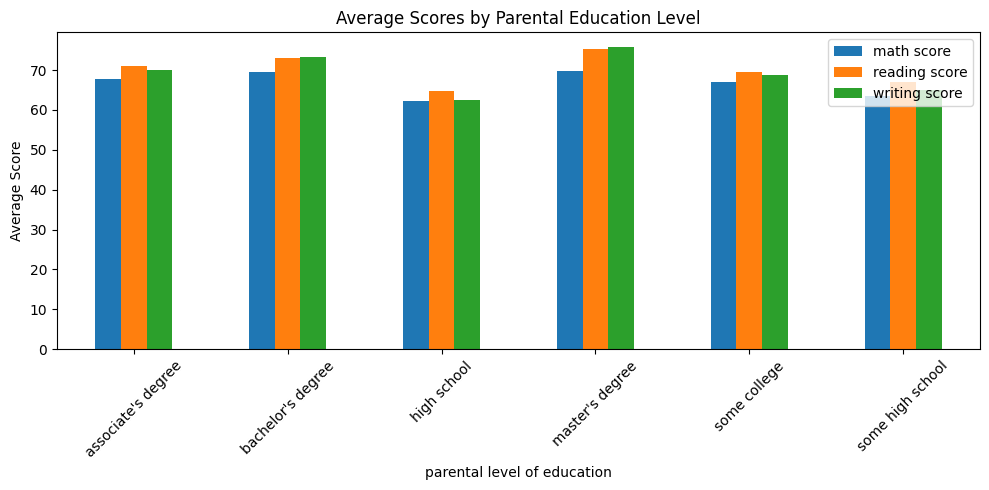

In [ ]:
# Visualization - Parental Education
df.groupby('parental level of education')[subjects].mean().plot(kind='bar', figsize=(10, 5))
plt.title('Average Scores by Parental Education Level')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('parental_education_analysis.png')
plt.show()

---
# ANSWERS:
 Q: Which group performs better?
  - Females score higher in reading & writing
  - Males score slightly higher in math
  - Students with parents having higher education perform better

 Q: Is there a clear trend?

  - Yes, higher parental education → better student performance
---

# SECTION 7: Relationship Analysis

In [ ]:
print("\n" + "=" * 60)
print("CORRELATION ANALYSIS")
print("=" * 60)

corr_matrix = df[subjects].corr()
print(corr_matrix.round(2))

print(f"\nMath vs Reading  : {df['math score'].corr(df['reading score']):.2f}")
print(f"Reading vs Writing: {df['reading score'].corr(df['writing score']):.2f}")


CORRELATION ANALYSIS
               math score  reading score  writing score
math score           1.00           0.82           0.80
reading score        0.82           1.00           0.95
writing score        0.80           0.95           1.00

Math vs Reading  : 0.82
Reading vs Writing: 0.95


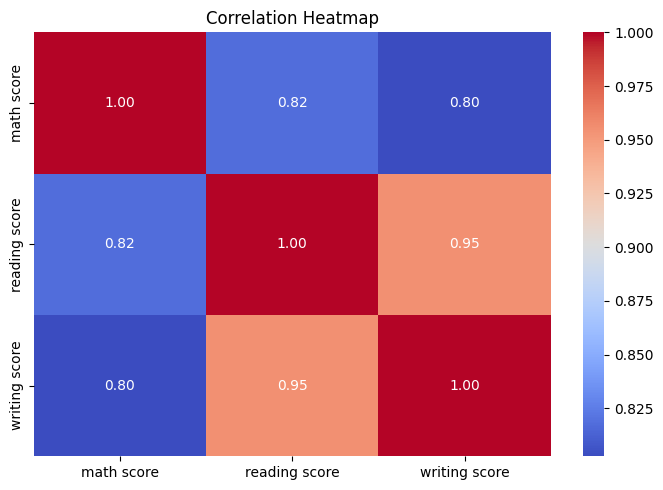

In [ ]:
# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

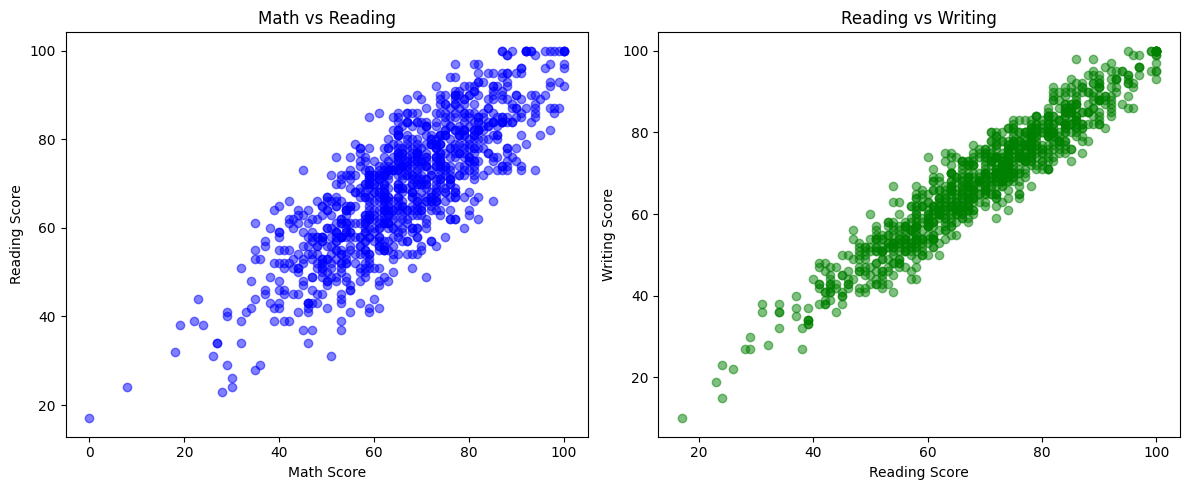

In [ ]:
# Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(df['math score'], df['reading score'], alpha=0.5, color='blue')
axes[0].set_title('Math vs Reading')
axes[0].set_xlabel('Math Score')
axes[0].set_ylabel('Reading Score')

axes[1].scatter(df['reading score'], df['writing score'], alpha=0.5, color='green')
axes[1].set_title('Reading vs Writing')
axes[1].set_xlabel('Reading Score')
axes[1].set_ylabel('Writing Score')

plt.tight_layout()
plt.savefig('scatter_plots.png')
plt.show()

---
# ANSWERS:
 Q: Which subjects are strongly related?
  - Reading vs Writing have the strongest correlation (~0.95)

 Q: Why might that be?

  - Both are language-based skills; students good at reading tend to write well too
---

# SECTION 8: Real-World Interpretation

---
1. FACTORS AFFECTING STUDENT PERFORMANCE:
   - Parental level of education (higher education = better scores)
   - Gender (females better in reading/writing, males in math)
   - Lunch type (standard lunch → better performance)
   - Test preparation course (completion improves scores)

2. SUBJECT NEEDING IMPROVEMENT:
   - Math score has the lowest average and highest variability
   - Needs more focused teaching and practice

3. IS PERFORMANCE CONSISTENT?
   - No, high standard deviation shows wide variation
   - Scores range from very low to very high across students

4. INSIGHTS FOR SCHOOL TO IMPROVE RESULTS:
   - Encourage test preparation course completion
   - Provide extra support for math
   - Address nutritional/lunch programs (linked to performance)
   - Engage parents with lower education in student learning
---